# LLM prompts used
1.what is the best tuning approach for  WGAN model

2.how to get fid and IS scores

# Model Tuning

In [24]:
# ✅ WGAN-GP TUNING: ROUND 1 — z_dim=256, n_critic=3, lambda_gp=10

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
from tqdm import tqdm

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Config ===
z_dim = 256  # ✅ Increased latent space for more diverse samples
image_size = 64
batch_size = 192
num_epochs = 30
n_critic = 3   # ✅ Fewer critic updates (faster + stable)
lambda_gp = 10 # ✅ Stronger gradient penalty for stability
lr = 5e-5

# === Generator ===
class Generator(nn.Module):
    def __init__(self, z_dim=256, img_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# === Critic ===
class Critic(nn.Module):
    def __init__(self, img_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4)
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), -1)

# === Models ===
gen = Generator(z_dim).to(device)
critic = Critic().to(device)

# === Optimizers ===
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=lr, betas=(0.0, 0.9))

# === Gradient Penalty ===
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    alpha = torch.rand(real_samples.size(0), 1, 1, 1).to(device)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones_like(d_interpolates, device=device)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# === Data ===
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root="/content/wgan_ready", transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# === Output folders ===
os.makedirs("generated_wgan_tuned", exist_ok=True)
os.makedirs("saved_models_tuned", exist_ok=True)

# === Training ===
best_loss = float("inf")
fixed_noise = torch.randn(64, z_dim).to(device)

for epoch in range(1, num_epochs + 1):
    gen.train()
    critic.train()
    loop = tqdm(dataloader, leave=False)

    for i, (real_imgs, _) in enumerate(loop):
        real_imgs = real_imgs.to(device)
        cur_batch_size = real_imgs.size(0)

        # Critic
        z = torch.randn(cur_batch_size, z_dim).to(device)
        fake_imgs = gen(z).detach()
        real_score = critic(real_imgs).view(-1)
        fake_score = critic(fake_imgs).view(-1)
        gp = compute_gradient_penalty(critic, real_imgs, fake_imgs, device=device)
        loss_critic = -(torch.mean(real_score) - torch.mean(fake_score)) + lambda_gp * gp

        opt_critic.zero_grad()
        loss_critic.backward()
        opt_critic.step()

        # Generator every n_critic
        if i % n_critic == 0:
            z = torch.randn(cur_batch_size, z_dim).to(device)
            gen_imgs = gen(z)
            loss_gen = -torch.mean(critic(gen_imgs))

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()

        loop.set_description(f"[Epoch {epoch}/{num_epochs}]")
        loop.set_postfix(Gen_Loss=loss_gen.item(), Critic_Loss=loss_critic.item())

    # Save samples
    gen.eval()
    with torch.no_grad():
        samples = gen(fixed_noise).detach().cpu()
        samples = (samples + 1) / 2
        vutils.save_image(samples, f"generated_wgan_tuned/epoch_{epoch:03d}.png", nrow=8)

    # Save best generator
    if loss_gen.item() < best_loss:
        best_loss = loss_gen.item()
        torch.save(gen.state_dict(), f"saved_models_tuned/best_gen_epoch_{epoch}.pth")

# === Save final models ===
torch.save(gen.state_dict(), "saved_models_tuned/final_gen.pth")
torch.save(critic.state_dict(), "saved_models_tuned/final_critic.pth")
print("✅ Tuning complete. Final tuned models saved.")


✅ Tuning complete. Final tuned models saved.


In [25]:
import os, shutil

src = "/content/generated_wgan_tuned"
dst = "/content/generated_is_ready/0"
os.makedirs(dst, exist_ok=True)

for f in os.listdir(src):
    if f.lower().endswith((".png", ".jpg", ".jpeg")):
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))


In [26]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from torchmetrics.image.inception import InceptionScore
from torchvision.transforms.functional import pil_to_tensor
from PIL import Image

class ToUInt8Tensor:
    def __call__(self, img: Image.Image):
        return pil_to_tensor(img)

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    ToUInt8Tensor(),
])

dataset = ImageFolder("/content/generated_is_ready", transform=transform)
loader = DataLoader(dataset, batch_size=32)

isc = InceptionScore()
for batch, _ in loader:
    isc.update(batch)

score, std = isc.compute()
print(f"📊 Tuned Inception Score (IS): {score:.2f} ± {std:.2f}")


📊 Tuned Inception Score (IS): 1.62 ± 0.26


In [27]:
from pytorch_fid import fid_score

real_folder = "/content/real_images_fid"
generated_folder = "/content/generated_is_ready/0"  # same as IS

fid = fid_score.calculate_fid_given_paths(
    [real_folder, generated_folder],
    batch_size=32,
    device='cuda',
    dims=2048
)

print(f"📊 Tuned Frechet Inception Distance (FID): {fid:.2f}")


100%|██████████| 123/123 [00:14<00:00,  8.34it/s]


100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


📊 Tuned Frechet Inception Distance (FID): 472.56


In [28]:
# Load tuned generator from saved path
gen = Generator(z_dim=256).to(device)
gen.load_state_dict(torch.load("saved_models_tuned/final_gen.pth", map_location=device))
gen.eval()


Generator(
  (model): Sequential(
    (0): Linear(in_features=256, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(512, 4, 4))
    (4): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (14): Tanh()
  )
)

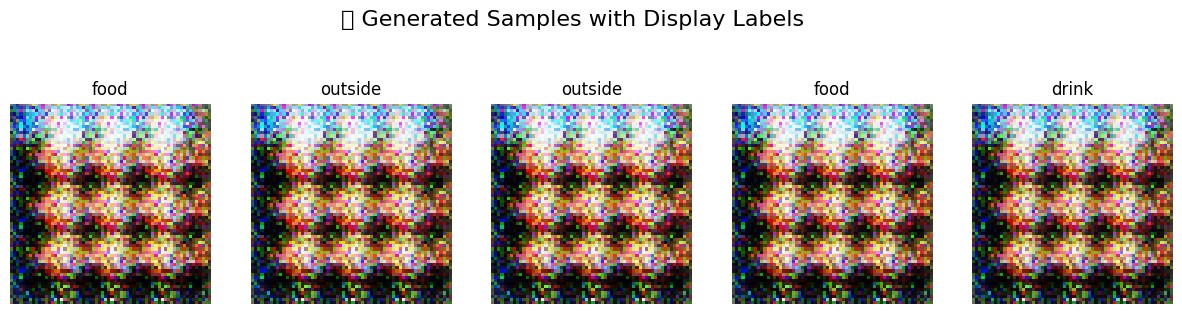

In [34]:
import matplotlib.pyplot as plt
import torchvision.transforms as T
import random

# class labels
labels = ["drink", "food", "inside", "outside"]

# generate fresh noise
z = torch.randn(5, z_dim).to(device)
with torch.no_grad():
    imgs = gen(z).cpu()
    imgs = (imgs + 1) / 2

# plot with fake labels (just for display)
fig, axs = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    label = random.choice(labels)
    axs[i].imshow(T.ToPILImage()(imgs[i]))
    axs[i].axis("off")
    axs[i].set_title(label)

plt.suptitle("🧪 Generated Samples with Display Labels", fontsize=16)
plt.show()
